<a href="https://colab.research.google.com/github/keropfia/95-Confidence-and-Prediction-Intervals-ComBase-with-qPCR-data/blob/main/E.%20coli%20recovery%20curve%20(refined).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install lmfit

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lmfit
from lmfit import Model

Transfer the data

In [23]:
df = pd.read_csv('/content/E. coli 6h best std.csv')
print(df)

    Time (h)    logN A    logN B    logN C   Average     STDEV
0          0  4.745387  5.247624  4.622189  4.871733  0.331308
1          1  4.431831  5.093030  4.816690  4.780517  0.332080
2          2  4.848561  4.698187  4.695128  4.747292  0.087715
3          3  4.121147  5.112399  4.279871  4.504472  0.532428
4          4  4.452748  4.398091  4.838774  4.563205  0.240210
5          5  5.021467       NaN  4.428474  4.724971  0.419309
6          6  4.096506  5.079778       NaN  4.588142  0.695279
7          7  4.612936  5.103330  4.759573  4.825280  0.251713
8          8  4.888685  5.380389  4.603205  4.957426  0.393126
9          9  5.668028  6.415957  5.526209  5.870064  0.478045
10        10  6.522193  7.334091  6.437124  6.764469  0.495137
11        11  7.496977  7.858820  7.161130  7.505642  0.348925
12        12  8.231397  8.318246  7.864138  8.137927  0.241052
13        13  8.921743  8.977335  8.507845  8.802308  0.256523
14        14  9.392079  8.923115  8.111489  8.808894  0

Define the model

In [24]:
def baranyi_dmfit(t, y0, y_end, umax, lag):
    """
    Baranyi growth model in log10 scale (DMFit-compatible)

    Parameters
    ----------
    t : time (h)
    y0 : initial log10 population
    y_end : final log10 population
    umax : maximum growth rate (log10 units per hour)
    lag : lag time (h)
    """
    ln10 = np.log(10.0)
    t = np.array(t)
    numerator = -1 + np.exp(ln10 * umax * lag) + np.exp(ln10 * umax * t)
    denominator = -1 + np.exp(ln10 * umax * t) + np.exp(ln10 * umax * lag) * 10 ** (y_end - y0)
    return y_end + np.log10(numerator / denominator)

Select the data

In [25]:
model = Model(baranyi_dmfit)

params = model.make_params(
    y0=df['logN C'].iloc[0],              # start from first measured log10 value
    y_end=df['logN C'].max(),             # use max observed value as guess
    umax=0.8,                           # initial guess (log10/h)
    lag=7                               # initial guess for lag time (h)
)

In [26]:
params['y0'].min = 0
params['y_end'].min = params['y0'].value
params['umax'].min = 0
params['lag'].min = 0

In [27]:
result = model.fit(df['logN C'], params, t=df['Time (h)'], nan_policy='omit')

In [28]:
t_smooth = np.linspace(df['Time (h)'].min(), df['Time (h)'].max(), 200)
y_pred = baranyi_dmfit(t_smooth, **result.best_values)

Print the figure

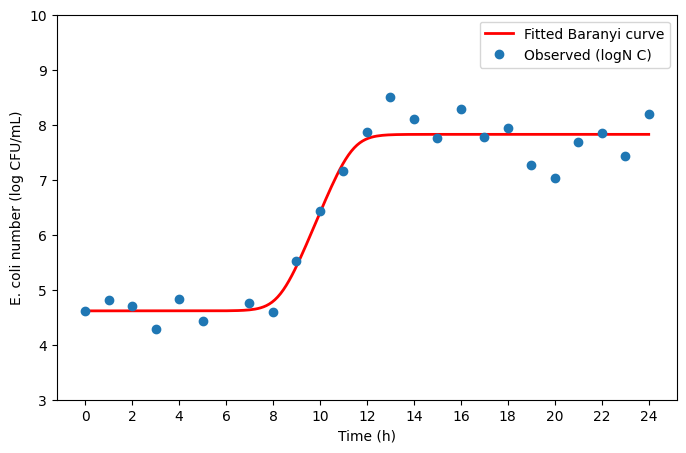

In [29]:
plt.figure(figsize=(8,5))
plt.errorbar(df['Time (h)'], df['logN C'], fmt='o', capsize=3, label='Observed (logN C)')
plt.plot(t_smooth, y_pred, 'r-', lw=2, label='Fitted Baranyi curve')
plt.xlabel('Time (h)')
plt.xticks(np.arange(0, max(t_smooth)+2, 2))
plt.ylabel('E. coli number (log CFU/mL)')
plt.yticks(np.arange(3, 10+1, 1))
plt.legend()
plt.show()

Generate the parameters

In [30]:
print(result.fit_report())

[[Model]]
    Model(baranyi_dmfit)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 51
    # data points      = 24
    # variables        = 4
    chi-square         = 2.36986923
    reduced chi-square = 0.11849346
    Akaike info crit   = -47.5652573
    Bayesian info crit = -42.8530420
    R-squared          = 0.95632592
[[Variables]]
    y0:     4.61559478 +/- 0.12924944 (2.80%) (init = 4.622189)
    y_end:  7.82477521 +/- 0.09761015 (1.25%) (init = 8.507845)
    umax:   1.05276449 +/- 0.27147620 (25.79%) (init = 0.8)
    lag:    8.29819984 +/- 0.49329491 (5.94%) (init = 7)
[[Correlations]] (unreported correlations are < 0.100)
    C(umax, lag)   = +0.8473
    C(y0, lag)     = +0.4349
    C(y0, umax)    = +0.1766
    C(y_end, umax) = -0.1346


Generate the fitting values

In [31]:
print("Time (t_smooth) values for the fitted curve:")
print(t_smooth)
print("\nPredicted logN (y_pred) values for the fitted curve:")
print(y_pred)

Time (t_smooth) values for the fitted curve:
[ 0.          0.12060302  0.24120603  0.36180905  0.48241206  0.60301508
  0.72361809  0.84422111  0.96482412  1.08542714  1.20603015  1.32663317
  1.44723618  1.5678392   1.68844221  1.80904523  1.92964824  2.05025126
  2.17085427  2.29145729  2.4120603   2.53266332  2.65326633  2.77386935
  2.89447236  3.01507538  3.13567839  3.25628141  3.37688442  3.49748744
  3.61809045  3.73869347  3.85929648  3.9798995   4.10050251  4.22110553
  4.34170854  4.46231156  4.58291457  4.70351759  4.8241206   4.94472362
  5.06532663  5.18592965  5.30653266  5.42713568  5.54773869  5.66834171
  5.78894472  5.90954774  6.03015075  6.15075377  6.27135678  6.3919598
  6.51256281  6.63316583  6.75376884  6.87437186  6.99497487  7.11557789
  7.2361809   7.35678392  7.47738693  7.59798995  7.71859296  7.83919598
  7.95979899  8.08040201  8.20100503  8.32160804  8.44221106  8.56281407
  8.68341709  8.8040201   8.92462312  9.04522613  9.16582915  9.28643216
  9.407